In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, recall_score

from sklearn.preprocessing import StandardScaler 

In [17]:
df=pd.read_csv("novagen_dataset.csv")

In [18]:
bools_col=["Diet_Type__Vegan","Diet_Type__Vegetarian","Blood_Group_AB","Blood_Group_B","Blood_Group_O"]

df[bools_col]=df[bools_col].astype(int)
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,0,1,1,0,0
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,0,0,1,0,0
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,1,0,0,0,0
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,1,0,0,1,0
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,0,1,0,1,0


In [19]:
X=df.drop("Target",axis=1)
y=df["Target"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#Model 1- RandomForest
rf=RandomForestClassifier(
    n_estimators=501,
    max_depth=4,
    oob_score=True
)

rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

print("oob_score:",rf.oob_score_*100)
print("Test_data_acc:",accuracy_score(y_test,y_pred)*100)
print("Test_data_recall:",recall_score(y_test,y_pred)*100)

In [7]:
#Model 2- xgboost
xgb_class=xgb.XGBClassifier(
    n_estimators=501,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_class.fit(X_train,y_train)

y_pred=xgb_class.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred)*100)
print("recall:",recall_score(y_test,y_pred)*100)

accuracy: 94.92146596858639
recall: 95.88353413654619


In [8]:
#Model 3 - SVC
svc=SVC()
svc.fit(X_train_scaled,y_train)
y_pred=svc.predict(X_test_scaled)
print("accuracy:",accuracy_score(y_test,y_pred)*100)
print("recall:",recall_score(y_test,y_pred)*100)

accuracy: 93.35078534031413
recall: 94.97991967871486


In [9]:
#model 4 - LogisticRegression 
lr=LogisticRegression(
    penalty="l2",
    solver="liblinear",
    random_state=42
)
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred)*100)
print("recall:",recall_score(y_test,y_pred)*100)

accuracy: 77.5392670157068
recall: 79.01606425702812


In [11]:
#Stacking
stk_class=StackingClassifier(
    estimators=[
        ("rf",rf),
        ("xgb",xgb_class),
        ("svc",svc)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

In [12]:
stk_class.fit(X_train,y_train)

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,n_estimators,501
,criterion,'gini'
,max_depth,4
,min_samples_split,2


In [18]:
y_pred=stk_class.predict(X_test)

print("accuracy:",accuracy_score(y_test,y_pred)*100)
print("recall:",recall_score(y_test,y_pred)*
      100)

accuracy: 94.86910994764398
recall: 95.88353413654619


In [19]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


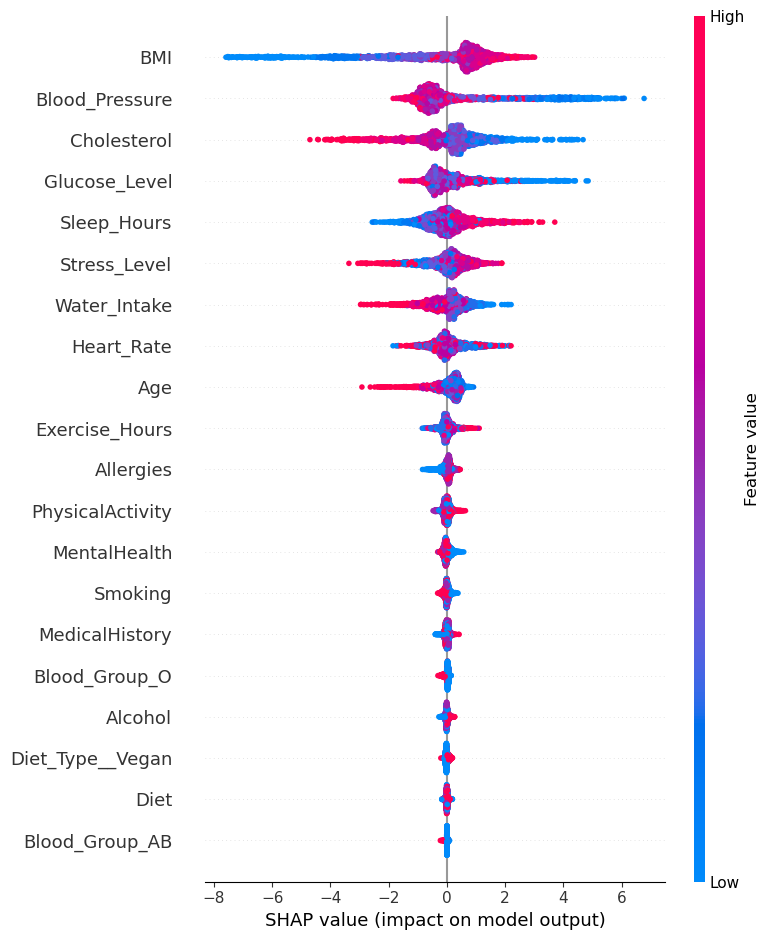

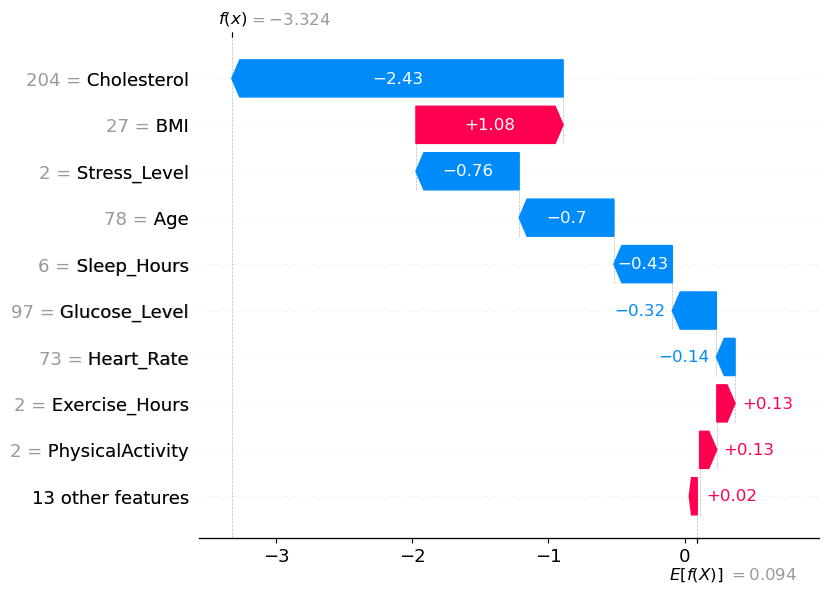

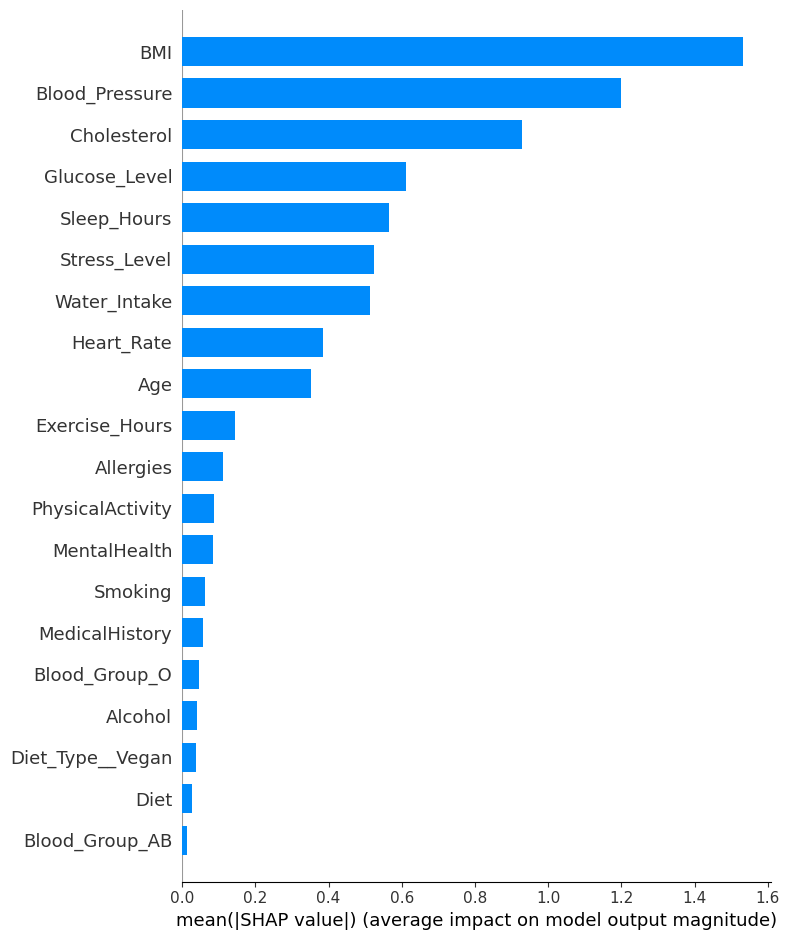

In [20]:
import shap

# SHAP for XGBoost (easiest — tree based)
explainer = shap.TreeExplainer(xgb_class)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Feature Importance (overall)
shap.summary_plot(shap_values, X_test)

# Plot 2 — Single patient explanation
shap.waterfall_plot(explainer(X_test)[0])

# Plot 3 — Bar chart of top features
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [15]:
import joblib

# Resave both files
joblib.dump(stk_class, 'health_classifier.pkl', protocol=2)  # protocol=2 for compatibility
joblib.dump(scaler,    'scaler.pkl', protocol=2)

print("✅ Models resaved!")

✅ Models resaved!
